In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [21]:
file_dir = Path("/home/admin123/Documents/SAP/Div_academy/data/car-sales-extended-missing-data.csv")
cars_csv_path = file_dir / "car-sales-extended-missing-data.csv"
housing_csv_path = Path("/home/admin123/Documents/SAP/Div_academy/data/housing.csv")

In [22]:
df = pd.read_csv(housing_csv_path)
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


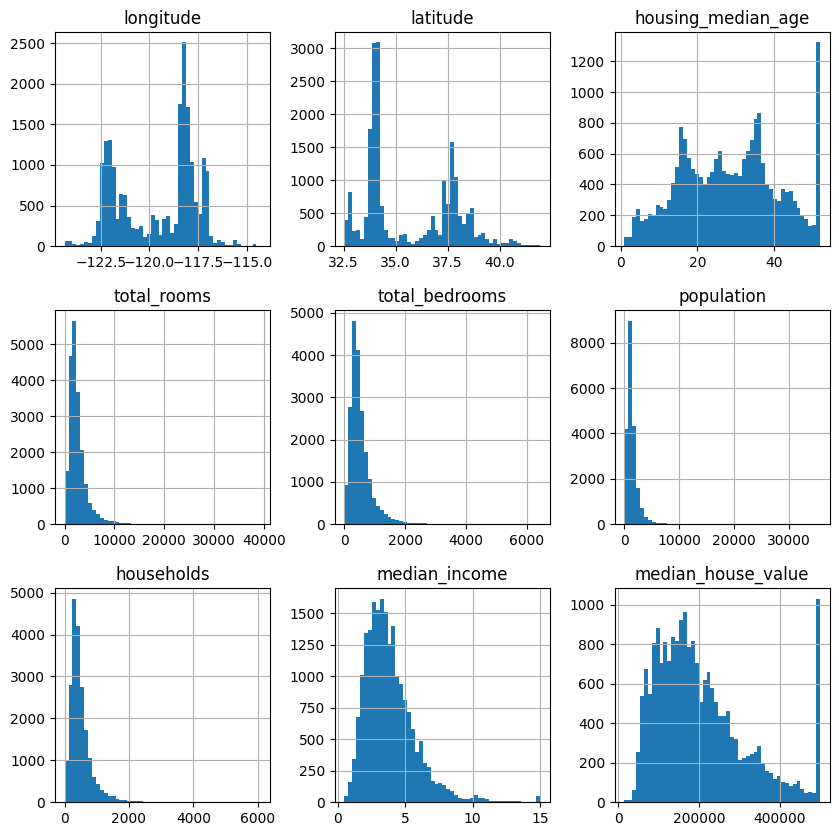

In [23]:
df.drop(columns=['ocean_proximity']).hist(figsize=(10, 10), bins=50)
plt.show()

In [24]:
arr = np.array([
    [1,2,3],
    [4,5,6]
])

arr[:, [0]] / arr[:, [1]]

array([[0.5],
       [0.8]])

In [25]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_cols = ['longitude',  'latitude', 'housing_median_age', ]
log_cols = ['total_rooms','total_bedrooms', 'population', 
            'households', 'median_income', 'median_house_value']
cat_cols = ['ocean_proximity']

log_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy = 'median')), 
    ("log", FunctionTransformer(func=np.log1p, inverse_func=np.expm1, feature_names_out='one-to-one')), 
    ("scl", StandardScaler()), 
])
ratio_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy = 'median')), 
    ("rat", FunctionTransformer(
        func=lambda arr: arr[:, [0]]/arr[:, [1]],
        feature_names_out=lambda *args, **kwargs: ['ratio'])
    ),
    ("scl", StandardScaler()), 
])
num_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy = 'median')), 
    ("scl", StandardScaler()), 
])
cat_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy = 'most_frequent')), 
    ("enc", OneHotEncoder()), 
])

preprocessing = ColumnTransformer([
    ("NUM", num_pipeline, num_cols), 
    ("CAT", cat_pipeline, cat_cols),
    ("LOG", log_pipeline, log_cols),
    ("RAT_tb/tr", ratio_pipeline, ['total_bedrooms', 'total_rooms']),
    ("RAT_p/tr", ratio_pipeline, ['population', 'total_rooms']),
    ("RAT_h/tr", ratio_pipeline, ['households', 'total_rooms']),
])

df_arr = preprocessing.fit_transform(df)
df_tr = pd.DataFrame(df_arr, columns=preprocessing.get_feature_names_out())
df_tr.tail()

,NUM__longitude,NUM__latitude,NUM__housing_median_age,CAT__ocean_proximity_<1H OCEAN,CAT__ocean_proximity_INLAND,CAT__ocean_proximity_ISLAND,CAT__ocean_proximity_NEAR BAY,CAT__ocean_proximity_NEAR OCEAN,LOG__total_rooms,LOG__total_bedrooms,LOG__population,LOG__households,LOG__median_income,LOG__median_house_value,RAT_tb/tr__ratio,RAT_p/tr__ratio,RAT_h/tr__ratio
20635,-0.758826,1.801647,-0.289187,0.0,1.0,0.0,0.0,0.0,-0.281605,-0.177042,-0.387090,-0.251243,-1.608366,-1.439305,0.165994,-0.038713,-0.024960
20636,-0.818722,1.806329,-0.845393,0.0,1.0,0.0,0.0,0.0,-1.441596,-1.435092,-1.559000,-1.705974,-0.691819,-1.461948,0.021671,-0.037589,-0.643217
20637,-0.823713,1.778237,-0.924851,0.0,1.0,0.0,0.0,0.0,0.122042,0.181548,-0.149112,0.121563,-1.460242,-1.145776,0.021134,-0.059697,-0.133748
20638,-0.873626,1.778237,-0.845393,0.0,1.0,0.0,0.0,0.0,-0.134015,-0.053635,-0.565257,-0.174439,-1.292722,-1.296760,0.093467,-0.076408,-0.213503
20639,-0.833696,1.750146,-1.004309,0.0,1.0,0.0,0.0,0.0,0.403995,0.511618,0.285399,0.399134,-0.826886,-1.201869,0.113275,-0.041989,-0.165834


In [30]:
df2 = pd.read_csv(Path('/home/admin123/Documents/SAP/Div_academy/data/insurance.csv'))
df2

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [42]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


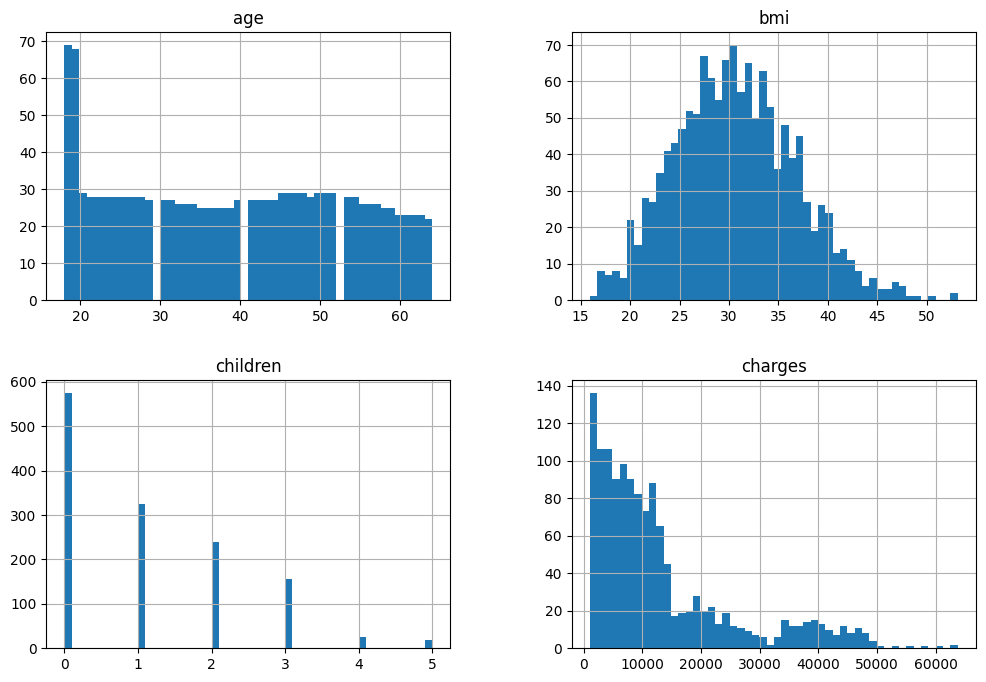

In [36]:
df2.hist(bins=50,figsize=(12,8))
plt.show()

In [63]:
num_cols2 = ['age', 'bmi', 'charges']
cat_cols2 = ['sex','smoker','region']
cat_cols2


['sex', 'smoker', 'region']

In [64]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_pipeline2 = Pipeline(
    [('scl',StandardScaler())]
)
cat_pipline2 = Pipeline(
    [('enc',OneHotEncoder())]
)

preprocessing2 = ColumnTransformer(
    [('NUM',num_pipeline2,num_cols2),
     ('CAT',cat_pipeline,cat_cols2)]

)
df2_arr = preprocessing2.fit_transform(df2)
pd.DataFrame(df2_arr,columns=preprocessing2.get_feature_names_out())


,NUM__age,NUM__bmi,NUM__charges,CAT__sex_female,CAT__sex_male,CAT__smoker_no,CAT__smoker_yes,CAT__region_northeast,CAT__region_northwest,CAT__region_southeast,CAT__region_southwest
0,-1.438764,-0.453320,0.298584,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.509965,0.509621,-0.953689,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-0.797954,0.383307,-0.728675,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-0.441948,-1.305531,0.719843,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.513149,-0.292556,-0.776802,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1333,0.768473,0.050297,-0.220551,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1334,-1.509965,0.206139,-0.914002,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1335,-1.509965,1.014878,-0.961596,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1336,-1.296362,-0.797813,-0.930362,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [66]:
df3 = pd.read_excel(Path('/home/admin123/Documents/SAP/Div_academy/data/Online Retail.xlsx'))
df3

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [67]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [77]:
df3_copy = df3.copy()
df3_copy.dropna()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [103]:
df3_copy[df3_copy['StockCode'] == '84406B']['Description'].value_counts()
df3_copy.drop('Description',axis='columns',inplace=True)

In [104]:
df3_copy.dropna()


,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,22613,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,4,2011-12-09 12:50:00,4.15,12680.0,France


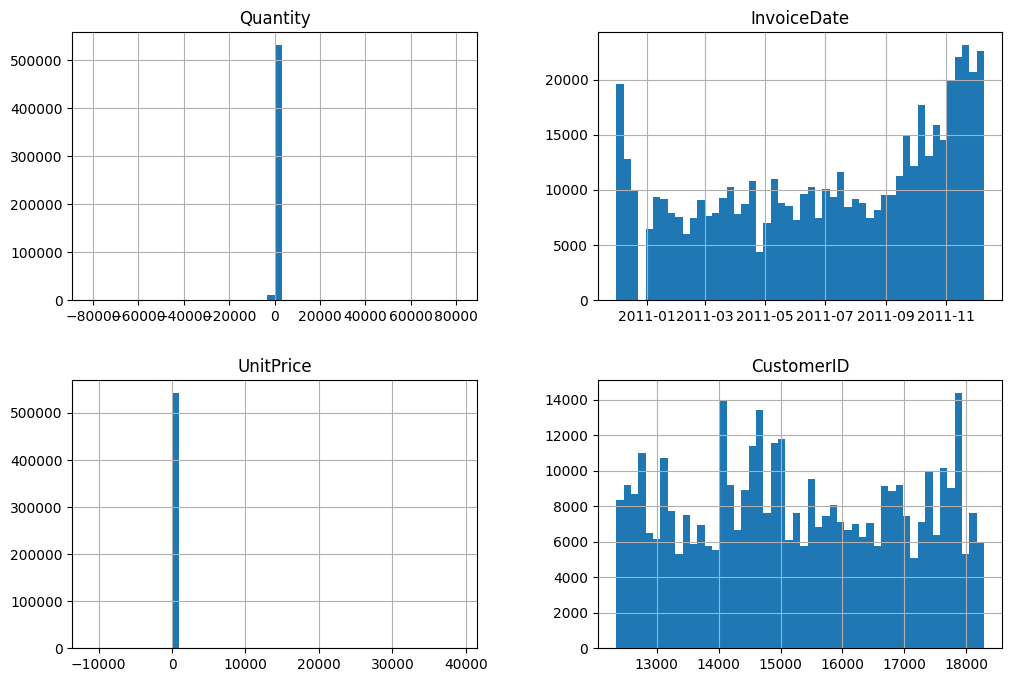

In [105]:
df3_copy.hist(bins=50,figsize=(12,8))
plt.show()